# Estudo sobre BN - ZnO 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Atomic Simulation Environment
from ase import Atoms
from ase.io import read, write
from ase.visualize import view

from pathlib import Path

Referência.

**Nonequilibrium BN-ZnO: Optical properties and excitonic effects from ﬁrst principles**

<div align="center">

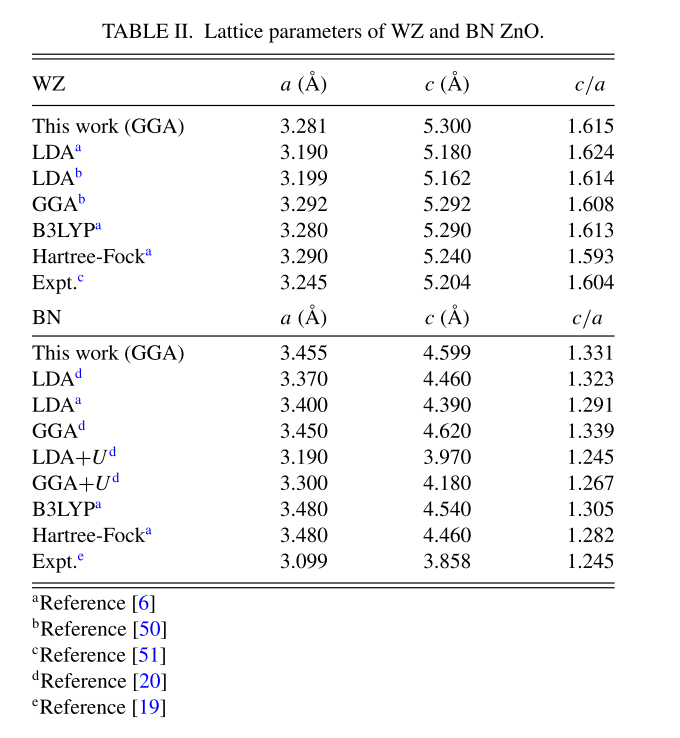

</div>


Com base nesses valores, vou propor um grid de:  

$a = \{2.90 \rightarrow 3.70\}$ em passos de $0.05 \AA$  
$c = \{3.70 \rightarrow 4.50\}$ em passos de $0.05 \AA$  

Equivale a um grid $16 \times 16$ $\rightarrow$ $(2.90, 3.60)\times (3.70, 4.50)$ = 256 estruturas

----


In [ ]:
# Ref: https://next-gen.materialsproject.org/materials/mp-2346983?formula=ZnO#summary
BN_ZnO_MP = read("BN-ZnO.cif")
BN_ZnO_MP


In [ ]:
print("ATOMIC POSITIONS:\n",BN_ZnO_MP.get_scaled_positions())
print("\nSYMBOLS:\n", *BN_ZnO_MP.get_chemical_symbols())
print("\nCELL PARAMETERS (a, b, c, alpha, beta, gamma)\n",*BN_ZnO_MP.cell.cellpar())

In [ ]:
def make_bn_zno(a: float, c: float) -> Atoms:
    """Produz um ZnO na fase h-BN (BN-ZnO)"""
    if a <= 0 or c <= 0:
        raise ValueError("Lattice parameters must be positive (a > 0, c > 0).")
    #  Vetores de rede Hexagonal
    a1 = [a, 0, 0]
    a2 = [-a/2.0, (np.sqrt(3)/2)*a, 0]
    a3 = [0, 0, c]
    cell = np.array([a1, a2, a3], dtype=float)

    # Coordenadas Fracionárias
    zn1 = (0.0, 0.0, 3.0/4.0)
    zn2 = (0.0, 0.0, 1.0/4.0)

    # O
    o1  = (1.0/3.0, 2.0/3.0, 1.0/4.0)
    o2  = (2.0/3.0, 1.0/3.0, 3.0/4.0)

    symbols = ["Zn", "Zn", "O", "O"]
    scaled_positions = [zn1, zn2, o1, o2]
    
    BN_ZnO = Atoms(
        symbols=symbols,
        scaled_positions=scaled_positions,
        cell=cell,
        pbc=True
    )
    return BN_ZnO


In [ ]:
# ---
# Sanity Check
a_teste, c_teste = 3.370, 4.460
atomos_de_teste = make_bn_zno()
atomos_de_teste.write("teste-{a_teste:.2f}-{c_teste:.2f}.cif")

In [ ]:
input_data = {
        "control": {
            "calculation": "scf",
            "prefix": "zno_bn_LDA",
            "pseudo_dir": "/home/jvc/ZnO_database/pseudos/ppdojo_LDA/",
            "outdir": "./",
            "verbosity": "low",
            "tprnfor": True,
            "tstress": True,
            "disk_io": "none",
        },
        "system": {
            "ibrav": 0,
            "ecutwfc": 80,
            "ecutrho": 320,
            "occupations": "fixed",
            "nbnd": 32  # 26 bandas + 6 vazias
        },
        "electrons": {
            "conv_thr": 1.0e-8,
            "mixing_beta": 0.3
        },
    }

pseudos =  {
    "Zn": "Zn_pseudo-dojo_NC_SR_LDA.upf",
    "O": "O_pseudo-dojo_NC_SR_LDA.upf"
            }

kpts = (6,6,4)
   
   
amin = 2.90
amax = 3.70

cmin = 3.70
cmax = 4.50
step = 0.05 # in Angstroms

Na = int(round((amax - amin)/step)) + 1
Nc = int(round((cmax - cmin)/step)) + 1

a_values = np.linspace(amin, amax, Na)
c_values = np.linspace(cmin, cmax, Nc)


In [ ]:

images: list[Atoms] = []
for a in a_values:
    for c in c_values:
        atoms = make_bn_zno(a, c)
        images.append(atoms)
        
print(f"{a_values.size = }")
print(f"{c_values.size = }")


In [ ]:
images

In [ ]:


job_dir = Path("BN-ZnO-E-vs-ac-inputs-scf")
job_dir.mkdir(exist_ok=True)

for atom in images:
    a, _, c = atom.cell.lengths()
    write(
        job_dir / f"scf-{a:.2f}-{c:.2f}.pwi",
        atom,
        pseudopotentials=pseudos,
        input_data=input_data,
        kpts=kpts,
        format="espresso-in"
    )

In [ ]:
# ---
# Sanity Check
a_teste, c_teste = 3.099, 3.858
atomos_de_teste = make_bn_zno(a_teste, c_teste)
# atomos_de_teste.write("teste-{a_teste:.2f}-{c_teste:.2f}.cif")

pw_fname = f"teste-{a_teste:.2f}-{c_teste:.2f}.in"
write(
        pw_fname,
        atomos_de_teste,
        pseudopotentials=pseudos,
        input_data=input_data,
        kpts=kpts,
        format="espresso-in"
    )

In [ ]:
out_atomos_de_teste = read(Path(pw_fname).with_suffix(".out"))
out_atomos_de_teste.get_stress()

## Contour Plot -  $E (a,c)$

In [ ]:
output_dir = Path("scf_Eac_scan_out")
outputs_paths: list[Path] = sorted(output_dir.rglob("*.pwo"))

rows = []
output_images = []
for i, f in enumerate(outputs_paths):
    atom = read(f)
    cell_energy = atom.get_total_energy()
    a, _, c = atom.cell.lengths()
    energy_fu = cell_energy / 2
    rows.append((a, c, energy_fu))
    output_images.append(atom)

print(f"{len(output_images)} arquivos '.pwo' processados!")    


In [ ]:
energies = np.array([atom.get_total_energy() for atom in output_images])

print(f"Energia mínima: {np.argmin(energies)}")
print(f"{output_images[np.argmin(energies)]}")

In [ ]:
idxmin = np.argmin(energies)
structure = output_images[idxmin]

Emin = energies.min()
filename = outputs_paths[idxmin]
razao_ca = structure.cell[2][2] / structure.cell[0][0]

print(f"{'Best Structure Summary':=^100}")
print(f"FILENAME: {filename}")
print(f"CELL: {structure.cell}\nLENGTHS:{structure.cell.lengths()}")
print(f"RAZAO C/A: {razao_ca:.2f}")
print(f"ENERGIA: {Emin}")
print(f"INDEX: {idxmin}\n")
print("FORCES: \n",structure.get_forces())
print("\nATOMIC POSITIONS:\n",structure.get_scaled_positions())
print("\nSTRESS:\n", structure.get_stress())
print("="*100)

Os parâmetros de rede obtidos foram $a = 3.25 \AA$ e $c = 4.45 \AA$

$h-BN$ ***pertence ao grupo espacial P6₃/mmc***

---



Matriz com Energias:

$$ E(a_i, c_j) $$

In [ ]:
E = np.zeros((len(a_values), len(c_values)))

for i, a in enumerate(a_values):
    for j, c in enumerate(c_values):
        filename = f"scf-{a:.2f}-{c:.2f}.pwo"
        atoms = read(f"scf_Eac_scan_out/{filename}", format="espresso-out", index=-1)
        E[i, j] = atoms.get_total_energy()

In [ ]:
a_values = np.arange(2.90, 3.60, 0.05)
c_values = np.arange(3.70, 4.50, 0.05)


A, C = np.meshgrid(a_values, c_values, indexing='ij')
print(A.shape)
print(C.shape)

E_plot = E - E.min()
fig, ax = plt.subplots(figsize=(6,5), layout="constrained", dpi=300)
ax.set_title("BN-ZnO")
ax.set_xlabel("a $(\AA)$", size=12)
ax.set_ylabel("c $(\AA)$", size=12)
cf = ax.contourf(A, C, E_plot, levels=40)
fig.colorbar(cf, ax=ax, label="$\Delta E $ (eV)")

# Estrutura do mínimo:

idx = np.unravel_index(E.argmin(), E.shape)
ax.scatter(
    A[idx],
    C[idx],
    marker="*",
    s=120,
    color="red"
)
plt.show()